# KKBOX 고객 이탈 예측 MLP

2017-01-31까지 관측된 고객 피처를 사용해 MLP 이진분류 모델을 학습한다.

LightGBM과 공정하게 비교하기 위해 동일한 조건을 사용한다.

- 동일한 `model_table_final.csv`
- 동일한 40개 입력 피처
- 동일한 train/valid/test split
- Valid에서 threshold 결정
- Test에서 최종 성능 평가
- 비교 지표: ROC-AUC, PR-AUC, Precision, Recall, F1

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print(
    "장치:",
    "cuda" if torch.cuda.is_available() else "cpu"
)

Python: c:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team\My_venv\Scripts\python.exe
PyTorch: 2.13.0+cpu
장치: cpu


In [2]:
PROCESSED_DIR = Path("../data/processed")
DATA_PATH = PROCESSED_DIR / "model_table_final.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

assert df["snapshot"].eq("2017-01-31").all()
assert df.isna().sum().sum() == 0
assert df["msno"].duplicated().sum() == 0
assert (df["days_since_last_txn"] < 0).sum() == 0

print("shape:", df.shape)
print("\nsplit:")
print(df["split"].value_counts())

print("\n이탈률:")
print(df.groupby("split")["is_churn"].mean())

print("\n딥러닝 입력 데이터 검증 완료")

shape: (992931, 44)

split:
split
train    695051
valid    148940
test     148940
Name: count, dtype: int64

이탈률:
split
test     0.063918
train    0.063923
valid    0.063925
Name: is_churn, dtype: float64

딥러닝 입력 데이터 검증 완료


## 입력 피처 분리 및 전처리

LightGBM과 동일한 피처를 사용하되 MLP가 학습할 수 있도록 변환한다.

- 식별자, 기준일, 분할 정보, Target은 입력에서 제외
- 수치형 피처는 StandardScaler로 표준화
- 범주형 피처는 One-Hot Encoding
- 스케일러와 인코더는 Train 데이터에만 학습
- Valid와 Test에는 Train에서 학습한 전처리 규칙을 그대로 적용
- 최종 입력 자료형은 float32

In [3]:
TARGET_COL = "is_churn"

DROP_COLS = [
    "msno",
    "snapshot",
    "split",
    TARGET_COL,
]

CATEGORICAL_COLS = [
    "city",
    "registered_via",
    "gender",
]

FEATURE_COLS = [
    col for col in df.columns
    if col not in DROP_COLS
]

NUMERIC_COLS = [
    col for col in FEATURE_COLS
    if col not in CATEGORICAL_COLS
]

assert len(FEATURE_COLS) == 40

train_df = df[df["split"] == "train"].copy()
valid_df = df[df["split"] == "valid"].copy()
test_df = df[df["split"] == "test"].copy()

y_train = train_df[TARGET_COL].to_numpy(
    dtype=np.float32
)
y_valid = valid_df[TARGET_COL].to_numpy(
    dtype=np.float32
)
y_test = test_df[TARGET_COL].to_numpy(
    dtype=np.float32
)

print("전체 피처 수:", len(FEATURE_COLS))
print("수치형 피처 수:", len(NUMERIC_COLS))
print("범주형 피처 수:", len(CATEGORICAL_COLS))

print("\n분할 크기")
print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))

전체 피처 수: 40
수치형 피처 수: 37
범주형 피처 수: 3

분할 크기
Train: 695051
Valid: 148940
Test : 148940


Train 기준 전처리

In [4]:
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
)

scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(
    train_df[NUMERIC_COLS]
).astype(np.float32)

X_valid_numeric = scaler.transform(
    valid_df[NUMERIC_COLS]
).astype(np.float32)

X_test_numeric = scaler.transform(
    test_df[NUMERIC_COLS]
).astype(np.float32)


encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.float32,
)

X_train_categorical = encoder.fit_transform(
    train_df[CATEGORICAL_COLS]
)

X_valid_categorical = encoder.transform(
    valid_df[CATEGORICAL_COLS]
)

X_test_categorical = encoder.transform(
    test_df[CATEGORICAL_COLS]
)


X_train = np.hstack([
    X_train_numeric,
    X_train_categorical,
]).astype(np.float32)

X_valid = np.hstack([
    X_valid_numeric,
    X_valid_categorical,
]).astype(np.float32)

X_test = np.hstack([
    X_test_numeric,
    X_test_categorical,
]).astype(np.float32)


OHE_FEATURE_NAMES = (
    encoder.get_feature_names_out(
        CATEGORICAL_COLS
    ).tolist()
)

FINAL_FEATURE_NAMES = (
    NUMERIC_COLS + OHE_FEATURE_NAMES
)

print("원본 피처 수:", len(FEATURE_COLS))
print("수치형 피처 수:", len(NUMERIC_COLS))
print(
    "범주형 원-핫 피처 수:",
    len(OHE_FEATURE_NAMES),
)
print(
    "최종 입력 피처 수:",
    len(FINAL_FEATURE_NAMES),
)

print("\n전처리 후 shape")
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)

print("\n자료형")
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

assert X_train.shape[1] == len(
    FINAL_FEATURE_NAMES
)
assert np.isfinite(X_train).all()
assert np.isfinite(X_valid).all()
assert np.isfinite(X_test).all()

print("\n전처리 결과 검증 완료")

원본 피처 수: 40
수치형 피처 수: 37
범주형 원-핫 피처 수: 31
최종 입력 피처 수: 68

전처리 후 shape
X_train: (695051, 68)
X_valid: (148940, 68)
X_test : (148940, 68)

자료형
X_train dtype: float32
y_train dtype: float32

전처리 결과 검증 완료


## PyTorch Dataset과 DataLoader 구성

전처리된 NumPy 배열을 PyTorch Tensor로 변환한다.

- Train만 `shuffle=True`
- Valid와 Test는 순서를 유지
- Windows Jupyter 환경의 안정성을 위해 `num_workers=0`
- CPU에서 큰 정형 데이터를 효율적으로 처리하기 위해 Batch Size는 4096
- 이진분류 Target 형태는 `[batch_size, 1]`

In [5]:
import gc

# 추후 Test 예측 결과와 고객 ID를 연결하기 위해 보존
test_msno = test_df["msno"].to_numpy(copy=True)

# 최종 배열을 만든 뒤 필요 없는 중간 배열과 DataFrame 해제
del (
    X_train_numeric,
    X_valid_numeric,
    X_test_numeric,
    X_train_categorical,
    X_valid_categorical,
    X_test_categorical,
)

del df, train_df, valid_df, test_df

gc.collect()

print("중간 데이터 메모리 정리 완료")

중간 데이터 메모리 정리 완료


In [6]:
from torch.utils.data import (
    TensorDataset,
    DataLoader,
)

RANDOM_SEED = 42
BATCH_SIZE = 4096

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

X_train_tensor = torch.from_numpy(X_train)
X_valid_tensor = torch.from_numpy(X_valid)
X_test_tensor = torch.from_numpy(X_test)

y_train_tensor = torch.from_numpy(
    y_train
).reshape(-1, 1)

y_valid_tensor = torch.from_numpy(
    y_valid
).reshape(-1, 1)

y_test_tensor = torch.from_numpy(
    y_test
).reshape(-1, 1)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

valid_dataset = TensorDataset(
    X_valid_tensor,
    y_valid_tensor,
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor,
)

generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    generator=generator,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
)

In [7]:
batch_X, batch_y = next(iter(train_loader))

print("전체 Dataset 크기")
print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

print("\n배치 개수")
print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches :", len(test_loader))

print("\n한 배치의 형태")
print("입력 shape :", batch_X.shape)
print("Target shape:", batch_y.shape)

print("\n자료형")
print("입력 dtype :", batch_X.dtype)
print("Target dtype:", batch_y.dtype)

assert batch_X.shape[1] == 68
assert batch_y.ndim == 2
assert batch_y.shape[1] == 1
assert batch_X.dtype == torch.float32
assert batch_y.dtype == torch.float32

print("\nDataset/DataLoader 검증 완료")

전체 Dataset 크기
Train: 695051
Valid: 148940
Test : 148940

배치 개수
Train batches: 170
Valid batches: 37
Test batches : 37

한 배치의 형태
입력 shape : torch.Size([4096, 68])
Target shape: torch.Size([4096, 1])

자료형
입력 dtype : torch.float32
Target dtype: torch.float32

Dataset/DataLoader 검증 완료


## MLP 모델 구조

정형 데이터를 입력받는 다층 퍼셉트론을 구성한다.

구조:

- 입력층: 68개 피처
- 은닉층 1: 128개 노드
- 은닉층 2: 64개 노드
- 출력층: 이탈 여부를 나타내는 Logit 1개
- 활성화 함수: ReLU
- Batch Normalization: 학습 안정화
- Dropout: 과적합 방지

손실 함수로 `BCEWithLogitsLoss`를 사용할 예정이므로 출력층에 Sigmoid를 넣지 않는다.

In [8]:
import torch.nn as nn

class ChurnMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x)

In [9]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

INPUT_DIM = X_train.shape[1]

model = ChurnMLP(
    input_dim=INPUT_DIM
).to(device)

print("사용 장치:", device)
print(model)

사용 장치: cpu
ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=68, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [10]:
sample_input = batch_X[:8].to(device)

model.eval()

with torch.no_grad():
    sample_output = model(sample_input)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("샘플 입력 shape :", sample_input.shape)
print("모델 출력 shape :", sample_output.shape)
print("전체 파라미터 수:", f"{parameter_count:,}")
print(
    "학습 파라미터 수:",
    f"{trainable_parameter_count:,}",
)

assert sample_output.shape == (8, 1)

print("\nMLP 구조 검증 완료")

샘플 입력 shape : torch.Size([8, 68])
모델 출력 shape : torch.Size([8, 1])
전체 파라미터 수: 17,537
학습 파라미터 수: 17,537

MLP 구조 검증 완료


## 클래스 불균형과 학습 설정

Train 데이터의 이탈률은 약 6.39%이므로 잔존 고객이 이탈 고객보다 약 14.6배 많다.

MLP가 다수 클래스인 잔존만 예측하는 현상을 줄이기 위해 `BCEWithLogitsLoss`의 `pos_weight`를 사용한다.

- 이탈 고객의 손실에 더 큰 가중치 적용
- 모델 출력에는 Sigmoid를 넣지 않음
- Optimizer는 AdamW 사용
- Early Stopping은 Valid PR-AUC 기준
- 최종 threshold는 Valid F1 기준으로 별도 결정

클래스 가중치를 사용하면 확률의 절대값이 달라질 수 있으므로 LightGBM과는 ROC-AUC, PR-AUC, F1 중심으로 비교한다.

In [11]:
negative_count = int(
    (y_train == 0).sum()
)

positive_count = int(
    (y_train == 1).sum()
)

positive_weight = (
    negative_count / positive_count
)

pos_weight_tensor = torch.tensor(
    [positive_weight],
    dtype=torch.float32,
    device=device,
)

print("잔존 고객 수:", f"{negative_count:,}")
print("이탈 고객 수:", f"{positive_count:,}")
print(
    "이탈률:",
    f"{positive_count / len(y_train) * 100:.2f}%",
)
print(
    "이탈 클래스 가중치:",
    f"{positive_weight:.4f}",
)

잔존 고객 수: 650,621
이탈 고객 수: 44,430
이탈률: 6.39%
이탈 클래스 가중치: 14.6437


손실함수와 Optimizer

In [12]:
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print("손실 함수:", criterion)
print("Optimizer:", type(optimizer).__name__)
print("Learning Rate:", LEARNING_RATE)
print("Weight Decay:", WEIGHT_DECAY)
print("최대 Epoch:", MAX_EPOCHS)
print(
    "Early Stopping Patience:",
    EARLY_STOPPING_PATIENCE,
)

손실 함수: BCEWithLogitsLoss()
Optimizer: AdamW
Learning Rate: 0.001
Weight Decay: 0.0001
최대 Epoch: 30
Early Stopping Patience: 5


## MLP 학습

각 Epoch에서 다음 과정을 수행한다.

1. Train 배치 순전파
2. 가중 Binary Cross Entropy 손실 계산
3. 역전파와 파라미터 업데이트
4. Valid Loss, ROC-AUC, PR-AUC 계산
5. Valid PR-AUC가 가장 높은 모델 상태 저장
6. 5 Epoch 연속 개선이 없으면 조기 종료

클래스 가중치가 적용된 Loss이므로 LightGBM의 LogLoss와 직접 비교하지 않고, 모델 선택은 Valid PR-AUC를 기준으로 한다.

In [13]:
import copy
import time

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

def evaluate_loader(
    model,
    data_loader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    probabilities = []
    targets = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)
            loss = criterion(logits, batch_y)

            total_loss += (
                loss.item() * len(batch_X)
            )

            batch_probabilities = torch.sigmoid(
                logits
            )

            probabilities.append(
                batch_probabilities
                .cpu()
                .numpy()
                .reshape(-1)
            )

            targets.append(
                batch_y
                .cpu()
                .numpy()
                .reshape(-1)
            )

    probabilities = np.concatenate(
        probabilities
    )

    targets = np.concatenate(targets)

    average_loss = (
        total_loss / len(data_loader.dataset)
    )

    auc = roc_auc_score(
        targets,
        probabilities,
    )

    pr_auc = average_precision_score(
        targets,
        probabilities,
    )

    return {
        "loss": average_loss,
        "auc": auc,
        "pr_auc": pr_auc,
        "probabilities": probabilities,
        "targets": targets,
    }

In [14]:
history = []

best_valid_pr_auc = -np.inf
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0

MIN_DELTA = 1e-5

training_start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start_time = time.time()

    model.train()
    total_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(batch_X)

        loss = criterion(
            logits,
            batch_y,
        )

        loss.backward()
        optimizer.step()

        total_train_loss += (
            loss.item() * len(batch_X)
        )

    train_loss = (
        total_train_loss
        / len(train_loader.dataset)
    )

    valid_result = evaluate_loader(
        model=model,
        data_loader=valid_loader,
        criterion=criterion,
        device=device,
    )

    epoch_seconds = (
        time.time() - epoch_start_time
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_result["loss"],
        "valid_auc": valid_result["auc"],
        "valid_pr_auc": valid_result["pr_auc"],
        "seconds": epoch_seconds,
    })

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Valid Loss: {valid_result['loss']:.5f} | "
        f"Valid AUC: {valid_result['auc']:.5f} | "
        f"Valid PR-AUC: "
        f"{valid_result['pr_auc']:.5f} | "
        f"{epoch_seconds:.1f}s"
    )

    improved = (
        valid_result["pr_auc"]
        > best_valid_pr_auc + MIN_DELTA
    )

    if improved:
        best_valid_pr_auc = (
            valid_result["pr_auc"]
        )

        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "\nEarly Stopping: "
                f"{EARLY_STOPPING_PATIENCE}개 Epoch "
                "연속 PR-AUC 개선 없음"
            )
            break

total_training_minutes = (
    time.time() - training_start_time
) / 60

model.load_state_dict(
    best_model_state
)

print("\n학습 완료")
print("Best Epoch:", best_epoch)
print(
    "Best Validation PR-AUC:",
    f"{best_valid_pr_auc:.5f}",
)
print(
    "전체 학습시간:",
    f"{total_training_minutes:.1f}분",
)

Epoch 01/30 | Train Loss: 0.91643 | Valid Loss: 0.84813 | Valid AUC: 0.86029 | Valid PR-AUC: 0.45917 | 48.4s
Epoch 02/30 | Train Loss: 0.85684 | Valid Loss: 0.82805 | Valid AUC: 0.86650 | Valid PR-AUC: 0.49641 | 35.5s
Epoch 03/30 | Train Loss: 0.83995 | Valid Loss: 0.81314 | Valid AUC: 0.87271 | Valid PR-AUC: 0.51859 | 37.5s
Epoch 04/30 | Train Loss: 0.82840 | Valid Loss: 0.80516 | Valid AUC: 0.87615 | Valid PR-AUC: 0.52720 | 37.0s
Epoch 05/30 | Train Loss: 0.82031 | Valid Loss: 0.79965 | Valid AUC: 0.87858 | Valid PR-AUC: 0.52779 | 35.6s
Epoch 06/30 | Train Loss: 0.81463 | Valid Loss: 0.79502 | Valid AUC: 0.88278 | Valid PR-AUC: 0.52961 | 30.5s
Epoch 07/30 | Train Loss: 0.81103 | Valid Loss: 0.78939 | Valid AUC: 0.88343 | Valid PR-AUC: 0.53561 | 30.9s
Epoch 08/30 | Train Loss: 0.80519 | Valid Loss: 0.78892 | Valid AUC: 0.88437 | Valid PR-AUC: 0.53704 | 31.3s
Epoch 09/30 | Train Loss: 0.80342 | Valid Loss: 0.78513 | Valid AUC: 0.88566 | Valid PR-AUC: 0.53862 | 30.6s
Epoch 10/30 | Train

## 학습 과정 시각화

Epoch별 Train/Valid Loss와 Valid ROC-AUC·PR-AUC를 확인한다.

Best Epoch 이후 PR-AUC가 개선되지 않아 Early Stopping이 발생했는지 시각적으로 검증한다.

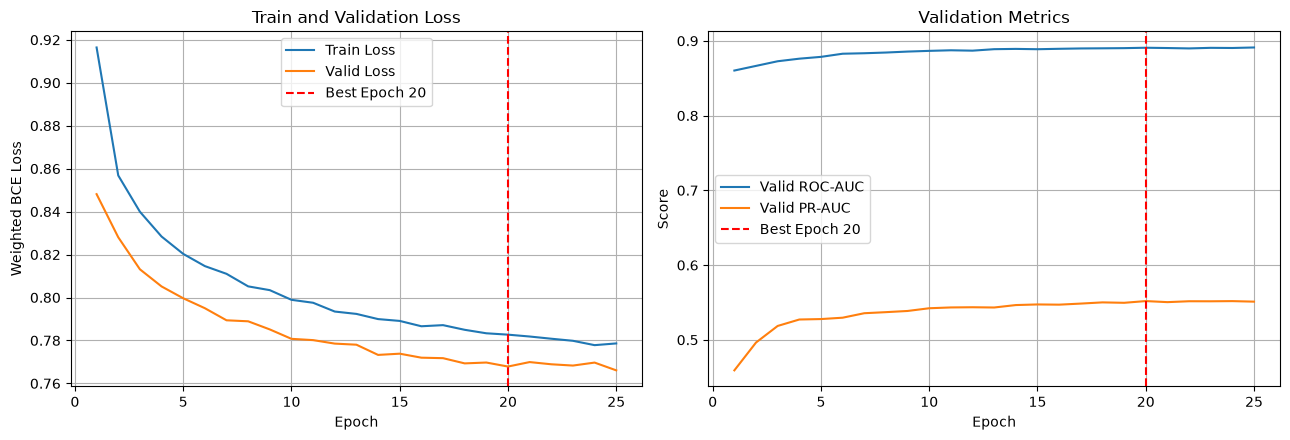

In [16]:
import matplotlib.pyplot as plt
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss",
)

axes[0].plot(
    history_df["epoch"],
    history_df["valid_loss"],
    label="Valid Loss",
)

axes[0].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch {best_epoch}",
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted BCE Loss")
axes[0].set_title("Train and Validation Loss")
axes[0].legend()
axes[0].grid(True)


axes[1].plot(
    history_df["epoch"],
    history_df["valid_auc"],
    label="Valid ROC-AUC",
)

axes[1].plot(
    history_df["epoch"],
    history_df["valid_pr_auc"],
    label="Valid PR-AUC",
)

axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch {best_epoch}",
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [17]:
from sklearn.metrics import (
    precision_recall_curve,
    precision_recall_fscore_support,
    confusion_matrix,
)

# Best Epoch 모델로 Valid 예측
valid_result = evaluate_loader(
    model=model,
    data_loader=valid_loader,
    criterion=criterion,
    device=device,
)

precisions, recalls, thresholds = (
    precision_recall_curve(
        valid_result["targets"],
        valid_result["probabilities"],
    )
)

f1_scores = (
    2 * precisions * recalls
    / (precisions + recalls + 1e-12)
)

best_threshold_index = (
    f1_scores[:-1].argmax()
)

best_threshold = thresholds[
    best_threshold_index
]

valid_pred_label = (
    valid_result["probabilities"]
    >= best_threshold
).astype(int)

valid_precision, valid_recall, valid_f1, _ = (
    precision_recall_fscore_support(
        valid_result["targets"],
        valid_pred_label,
        average="binary",
    )
)

print("===== VALID 성능 =====")
print(
    f"AUC: {valid_result['auc']:.4f}  "
    f"PR-AUC: {valid_result['pr_auc']:.4f}"
)
print(
    f"최적 threshold: {best_threshold:.4f}"
)
print(
    f"Precision: {valid_precision:.4f}  "
    f"Recall: {valid_recall:.4f}  "
    f"F1: {valid_f1:.4f}"
)

===== VALID 성능 =====
AUC: 0.8908  PR-AUC: 0.5519
최적 threshold: 0.8600
Precision: 0.5415  Recall: 0.5309  F1: 0.5361


In [18]:
# Valid에서 결정한 threshold를 Test에 그대로 적용
test_result = evaluate_loader(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

test_pred_label = (
    test_result["probabilities"]
    >= best_threshold
).astype(int)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        test_result["targets"],
        test_pred_label,
        average="binary",
    )
)

test_cm = confusion_matrix(
    test_result["targets"],
    test_pred_label,
)

print("===== TEST 성능 =====")
print(
    f"AUC: {test_result['auc']:.4f}  "
    f"PR-AUC: {test_result['pr_auc']:.4f}"
)
print(
    f"Precision: {test_precision:.4f}  "
    f"Recall: {test_recall:.4f}  "
    f"F1: {test_f1:.4f}"
)

print("\nConfusion Matrix:")
print(test_cm)

===== TEST 성능 =====
AUC: 0.8941  PR-AUC: 0.5513
Precision: 0.5405  Recall: 0.5382  F1: 0.5394

Confusion Matrix:
[[135064   4356]
 [  4396   5124]]


## LightGBM과 MLP 성능 비교

동일한 데이터, 피처, 분할을 사용해 비교한 결과 LightGBM이 ROC-AUC, PR-AUC, Recall, F1에서 MLP보다 우수했다.

정형 데이터에서는 트리 기반 모델이 변수 간 비선형 관계와 조건부 상호작용을 효율적으로 학습하기 때문에 단순 MLP보다 좋은 결과가 나타날 수 있다.

MLP는 Precision이 소폭 높았지만 실제 이탈자를 찾아내는 Recall과 종합적인 PR-AUC가 낮아 최종 모델은 LightGBM으로 선정한다.

In [20]:
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        path
        for path in [
            CURRENT_DIR,
            *CURRENT_DIR.parents,
        ]
        if (
            (path / "preprocessing").is_dir()
            and (path / "modeling").is_dir()
            and (path / ".gitignore").exists()
        )
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "프로젝트 루트를 찾을 수 없습니다."
    )

PROCESSED_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("프로젝트 루트:", PROJECT_ROOT)
print("Processed 경로:", PROCESSED_DIR)
print("Models 경로:", MODELS_DIR)

프로젝트 루트: C:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team-modify
Processed 경로: C:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team-modify\data\processed
Models 경로: C:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team-modify\models


In [21]:
# 비교표 저장
MODELS_DIR = PROJECT_ROOT / "models"

comparison_with_mlp = pd.DataFrame([
    {
        "model": "LightGBM",
        "auc": 0.9011,
        "pr_auc": 0.5753,
        "precision": 0.5346,
        "recall": 0.5681,
        "f1": 0.5508,
    },
    {
        "model": "MLP",
        "auc": test_result["auc"],
        "pr_auc": test_result["pr_auc"],
        "precision": test_precision,
        "recall": test_recall,
        "f1": test_f1,
    },
])

comparison_with_mlp

,model,auc,pr_auc,precision,recall,f1
0,LightGBM,0.9011,0.575300,0.534600,0.568100,0.550800
1,MLP,0.8941,0.551338,0.540506,0.538235,0.539368


In [22]:
#MLP 모델과 전처리기 저장

import json
import joblib

MODEL_PATH = (
    MODELS_DIR
    / "mlp_20170131_state_dict.pt"
)

PREPROCESSOR_PATH = (
    MODELS_DIR
    / "mlp_20170131_preprocessor.joblib"
)

METADATA_PATH = (
    MODELS_DIR
    / "mlp_20170131_meta.json"
)

HISTORY_PATH = (
    MODELS_DIR
    / "mlp_20170131_history.csv"
)

PREDICTION_PATH = (
    PROCESSED_DIR
    / "mlp_test_predictions_20170131.csv"
)

torch.save(
    {
        "model_state_dict": {
            name: tensor.cpu()
            for name, tensor
            in model.state_dict().items()
        },
        "input_dim": INPUT_DIM,
        "best_epoch": best_epoch,
    },
    MODEL_PATH,
)

joblib.dump(
    {
        "scaler": scaler,
        "encoder": encoder,
        "numeric_cols": NUMERIC_COLS,
        "categorical_cols": CATEGORICAL_COLS,
        "feature_names": FINAL_FEATURE_NAMES,
    },
    PREPROCESSOR_PATH,
)

metadata = {
    "feature_cutoff": "2017-01-31",
    "input_dim": int(INPUT_DIM),
    "hidden_dims": [128, 64],
    "activation": "ReLU",
    "best_epoch": int(best_epoch),
    "positive_weight": float(positive_weight),
    "threshold": float(best_threshold),
    "valid_auc": float(valid_result["auc"]),
    "valid_pr_auc": float(valid_result["pr_auc"]),
    "valid_precision": float(valid_precision),
    "valid_recall": float(valid_recall),
    "valid_f1": float(valid_f1),
    "test_auc": float(test_result["auc"]),
    "test_pr_auc": float(test_result["pr_auc"]),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1),
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

history_df.to_csv(
    HISTORY_PATH,
    index=False,
)

prediction_df = pd.DataFrame({
    "msno": test_msno,
    "is_churn": test_result["targets"].astype(int),
    "churn_probability": test_result["probabilities"],
    "predicted_churn": test_pred_label,
})

prediction_df.to_csv(
    PREDICTION_PATH,
    index=False,
)

print("MLP 모델 저장:", MODEL_PATH)
print("전처리기 저장:", PREPROCESSOR_PATH)
print("메타데이터 저장:", METADATA_PATH)
print("학습 이력 저장:", HISTORY_PATH)
print("Test 예측 저장:", PREDICTION_PATH)

MLP 모델 저장: C:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team-modify\models\mlp_20170131_state_dict.pt
전처리기 저장: C:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team-modify\models\mlp_20170131_preprocessor.joblib
메타데이터 저장: C:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team-modify\models\mlp_20170131_meta.json
학습 이력 저장: C:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team-modify\models\mlp_20170131_history.csv
Test 예측 저장: C:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team-modify\data\processed\mlp_test_predictions_20170131.csv
